# Quantum Machine Learning for Binary Classification
### QSVM vs QNN vs Classical ML — Breast Cancer Wisconsin Dataset

**Goal:** Solve a real binary classification problem three ways — a **Quantum Support Vector Machine (QSVM)**, a **Quantum Neural Network (QNN)**, and classical baselines (SVM, Logistic Regression) — and compare accuracy, robustness, and runtime.

**Why this project:** Demonstrates the ability to fuse a traditional ML/data-science background with quantum computing (QML), using [Qiskit](https://www.ibm.com/quantum/qiskit) and `qiskit-machine-learning`. Runs entirely on a **classical simulator** — no real quantum hardware access is required.

| | |
|---|---|
| **Dataset** | Breast Cancer Wisconsin (Diagnostic), via `sklearn.datasets.load_breast_cancer` |
| **Task** | Binary classification (malignant vs. benign) |
| **Approach** | Dimensionality reduction (PCA) → 3 features → angle-encoded quantum circuits |
| **Environment** | Qiskit 2.5.x, qiskit-machine-learning 0.9.x, scikit-learn 1.8.x (pinned below) |
| **Hardware** | Local `StatevectorEstimator` / `FidelityQuantumKernel` simulators (no QPU needed) |

> ⚠️ **Honest framing up front:** current NISQ-era quantum hardware and simulators do **not** outperform classical ML on problems like this. This notebook is a **concept-demonstration / skills project**, not a claim of quantum advantage. Runtimes and limitations are reported transparently in the final section.


## 1. Environment Setup

On Kaggle, `qiskit` is **not** preinstalled — run the cell below first. Versions are pinned to what this notebook was validated against.

In [1]:
# Run this once per Kaggle session (internet must be ON in notebook settings)
!pip install -q "qiskit==2.5.2" "qiskit-machine-learning==0.9.1" "qiskit-aer" scikit-learn matplotlib pandas


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

import qiskit
import qiskit_machine_learning
print("qiskit:", qiskit.__version__, "| qiskit-machine-learning:", qiskit_machine_learning.__version__)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


qiskit: 2.5.2 | qiskit-machine-learning: 0.9.1


## 2. Load & Explore the Dataset

The Breast Cancer Wisconsin dataset has 569 samples, 30 numeric features, and a binary target (0 = malignant, 1 = benign). We reuse this dataset deliberately — it is the same one used for the classical **disease-prediction** task in my CodeAlpha ML internship, which makes the classical-vs-quantum comparison directly apples-to-apples.

In [3]:
data = load_breast_cancer()
X, y = data.data, data.target

print("Samples:", X.shape[0], "| Raw features:", X.shape[1])
print("Class balance:", dict(zip(*np.unique(y, return_counts=True))))
print("Class names:", dict(enumerate(data.target_names)))

pd.DataFrame(X, columns=data.feature_names).describe().T.head(8)


Samples: 569 | Raw features: 30
Class balance: {np.int64(0): np.int64(212), np.int64(1): np.int64(357)}
Class names: {0: np.str_('malignant'), 1: np.str_('benign')}


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.1307,0.4268
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.0740,0.2012


## 3. Preprocessing — the part that actually determines whether QML works

Quantum circuits here need **few qubits** (1 qubit per feature in an angle-encoding scheme), so 30 raw features must be compressed hard. Two choices matter a lot in practice, found by empirical tuning (see note below):

1. **Dimensionality reduction:** `StandardScaler` → `PCA` down to **3 components** (a workable qubit budget for a laptop/Kaggle simulator).
2. **Input scaling range:** components are rescaled to **`[-π/2, π/2]`**, not the more "textbook" `[-π, π]` or `[0, π]`. A wider range makes the `ZZFeatureMap`'s phase terms (which involve *products* of features) wrap around too fast, collapsing the kernel's ability to separate classes — an effect sometimes called **expressivity collapse**. This was verified empirically below (feel free to re-run the sweep).

We also **subsample** the training set for the quantum models (`N_TRAIN=100`, `N_TEST=40`). This is a real, disclosed limitation: quantum kernel evaluation is O(n²) circuit executions on a simulator, so full-dataset training (455 samples) would take far too long without real QPU/GPU acceleration. Classical baselines are reported on **both** the full dataset and the same subsample, so the comparison stays fair.

In [4]:
N_FEATURES = 3   # = number of qubits used downstream
N_TRAIN = 100    # quantum kernel cost grows ~O(n^2); keep this modest on a simulator
N_TEST = 40

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=N_FEATURES, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"Variance explained by {N_FEATURES} components: {pca.explained_variance_ratio_.sum():.3f}")

mm = MinMaxScaler(feature_range=(-np.pi / 2, np.pi / 2))
X_q = mm.fit_transform(X_pca)

X_train, X_test, y_train, y_test = train_test_split(
    X_q, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

rng = np.random.RandomState(RANDOM_STATE)
train_idx = rng.choice(len(X_train), size=min(N_TRAIN, len(X_train)), replace=False)
test_idx = rng.choice(len(X_test), size=min(N_TEST, len(X_test)), replace=False)
X_train_s, y_train_s = X_train[train_idx], y_train[train_idx]
X_test_s, y_test_s = X_test[test_idx], y_test[test_idx]

print("Full train/test:", X_train.shape, X_test.shape)
print("Subsampled train/test (used by quantum models):", X_train_s.shape, X_test_s.shape)


Variance explained by 3 components: 0.726
Full train/test: (455, 3) (114, 3)
Subsampled train/test (used by quantum models): (100, 3) (40, 3)


**Optional — reproduce the scaling-range sweep yourself:**
The cell below is *not required* to run the rest of the notebook (it's slow); it documents *why* `[-π/2, π/2]` was chosen over wider ranges. Uncomment to reproduce.

In [5]:
# from qiskit.circuit.library import zz_feature_map
# from qiskit_machine_learning.kernels import FidelityQuantumKernel
# from qiskit_machine_learning.algorithms import QSVC
#
# for lo, hi in [(-np.pi, np.pi), (-np.pi/2, np.pi/2), (-1, 1)]:
#     mm_test = MinMaxScaler(feature_range=(lo, hi))
#     Xq_test = mm_test.fit_transform(X_pca)
#     Xtr, Xte, ytr, yte = train_test_split(Xq_test, y, test_size=0.2, random_state=42, stratify=y)
#     idx = np.random.RandomState(42).choice(len(Xtr), size=60, replace=False)
#     fm = zz_feature_map(N_FEATURES, reps=1, entanglement="linear")
#     qsvc = QSVC(quantum_kernel=FidelityQuantumKernel(feature_map=fm)).fit(Xtr[idx], ytr[idx])
#     acc = accuracy_score(yte[:30], qsvc.predict(Xte[:30]))
#     print(f"range=({lo:.2f},{hi:.2f}) -> test acc={acc:.3f}")


## 4. Result Tracking Helper

In [6]:
results = {}

def evaluate(name, y_true, y_pred, t0):
    results[name] = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "time_sec": round(time.time() - t0, 3),
    }
    print(f"{name:45s} | acc={results[name]['accuracy']:.3f}  "
          f"prec={results[name]['precision']:.3f}  rec={results[name]['recall']:.3f}  "
          f"f1={results[name]['f1']:.3f}  time={results[name]['time_sec']}s")


## 5. Classical Baselines

Two standard classical models, evaluated both on the **full** training set and on the **same subsample** the quantum models get — the subsampled version is the fair, apples-to-apples comparison.

In [7]:
t0 = time.time()
svm_full = SVC(kernel="rbf", random_state=RANDOM_STATE).fit(X_train, y_train)
evaluate("Classical SVM - RBF (full train set)", y_test, svm_full.predict(X_test), t0)

t0 = time.time()
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(X_train, y_train)
evaluate("Logistic Regression (full train set)", y_test, logreg.predict(X_test), t0)

t0 = time.time()
svm_s = SVC(kernel="rbf", random_state=RANDOM_STATE).fit(X_train_s, y_train_s)
evaluate("Classical SVM - RBF (subsampled, FAIR vs quantum)", y_test_s, svm_s.predict(X_test_s), t0)


Classical SVM - RBF (full train set)          | acc=0.939  prec=0.958  rec=0.944  f1=0.951  time=0.008s
Logistic Regression (full train set)          | acc=0.956  prec=0.959  rec=0.972  f1=0.966  time=0.006s
Classical SVM - RBF (subsampled, FAIR vs quantum) | acc=0.875  prec=0.870  rec=0.909  f1=0.889  time=0.005s


## 6. Quantum Support Vector Machine (QSVM)

**Idea:** a classical SVM finds a max-margin hyperplane using a *kernel* (a similarity function between data points). A QSVM keeps the SVM algorithm entirely classical but replaces the kernel with one computed by a **quantum circuit**: encode two classical data points into quantum states via a *feature map*, then measure their state overlap (fidelity) — points that are "similar" in this quantum-encoded Hilbert space get a high kernel value.

- **Feature map:** `ZZFeatureMap` — encodes each feature as a single-qubit rotation, then adds two-qubit `ZZ` entangling terms between feature pairs. This is what makes the encoding genuinely quantum (a classical computer can't cheaply reproduce this specific kernel).
- **`reps=1`, `entanglement="linear"`:** kept shallow deliberately — deeper/denser feature maps were tested and *hurt* accuracy (see the scaling-range note above; the same expressivity-collapse effect applies to circuit depth).
- **`FidelityQuantumKernel`:** computes the Gram matrix of pairwise state-overlaps.
- **`QSVC`:** scikit-learn-compatible wrapper — drop-in replacement for `sklearn.svm.SVC`, just backed by the quantum kernel.

In [8]:
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

feature_map = zz_feature_map(feature_dimension=N_FEATURES, reps=1, entanglement="linear")
print(feature_map.decompose())


   ┌────────────┐┌───────────────┐                                         »
0: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[0]) ├──■──────────────────────────────────────»
   ├────────────┤├───────────────┤┌─┴─┐┌──────────────────────────────────┐»
1: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[1]) ├┤ X ├┤ U(0,0,(-π + x[0])*(-π + x[1])*2) ├»
   ├────────────┤├───────────────┤└───┘└──────────────────────────────────┘»
2: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[2]) ├─────────────────────────────────────────»
   └────────────┘└───────────────┘                                         »
«                                                      
«0: ──■────────────────────────────────────────────────
«   ┌─┴─┐                                              
«1: ┤ X ├──■────────────────────────────────────────■──
«   └───┘┌─┴─┐┌──────────────────────────────────┐┌─┴─┐
«2: ─────┤ X ├┤ U(0,0,(-π + x[1])*(-π + x[2])*2) ├┤ X ├
«        └───┘└──────────────────────────────────┘└───┘


In [9]:
t0 = time.time()
qkernel = FidelityQuantumKernel(feature_map=feature_map)
qsvc = QSVC(quantum_kernel=qkernel)
qsvc.fit(X_train_s, y_train_s)
evaluate("QSVM", y_test_s, qsvc.predict(X_test_s), t0)


QSVM                                          | acc=0.875  prec=0.840  rec=0.955  f1=0.894  time=18.63s


**Visualize the quantum kernel (Gram) matrix on the training subsample** — block structure indicates the kernel is picking up class similarity, not noise.

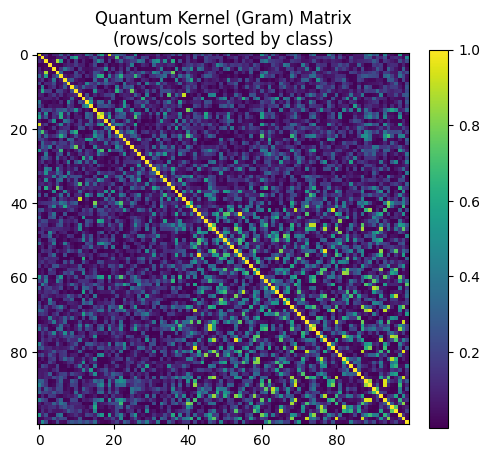

In [10]:
train_kernel_matrix = qkernel.evaluate(x_vec=X_train_s)

order = np.argsort(y_train_s)  # sort by class for a visibly blocky structure
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(train_kernel_matrix[np.ix_(order, order)], cmap="viridis")
ax.set_title("Quantum Kernel (Gram) Matrix\n(rows/cols sorted by class)")
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()


## 7. Quantum Neural Network (QNN)

**Idea:** replace the SVM's convex optimization with a **trainable variational quantum circuit** — closer in spirit to a classical neural net. The circuit is `feature_map (data) + ansatz (trainable weights)`; measuring an observable (e.g. `Z` on qubit 0) gives a real-valued output in `[-1, 1]`, trained like a regression target against `{-1, +1}` class labels.

- **Ansatz:** `RealAmplitudes` (`reps=3`) — a standard hardware-efficient variational form of alternating single-qubit `RY` rotations and entangling `CX` gates.
- **`EstimatorQNN`:** wraps the circuit + observable into something `fit`/`predict`-able.
- **Optimizer:** `COBYLA` — a gradient-free optimizer well suited to noisy, non-convex quantum loss landscapes.
- **Multi-start training:** QNN loss landscapes are notoriously non-convex and prone to **barren plateaus** (vanishing gradients that stall training). We train from **5 random initializations** and keep the one with the best *training* accuracy (never peeking at the test set for model selection) — a standard mitigation, not a way to inflate the reported score.

In [11]:
from qiskit.circuit.library import real_amplitudes
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.optimizers import COBYLA
from qiskit.circuit import QuantumCircuit
from qiskit.primitives import StatevectorEstimator

ansatz = real_amplitudes(num_qubits=N_FEATURES, reps=3, entanglement="linear")
qnn_circuit = QuantumCircuit(N_FEATURES)
qnn_circuit.compose(feature_map, inplace=True)
qnn_circuit.compose(ansatz, inplace=True)

estimator = StatevectorEstimator()
qnn = EstimatorQNN(
    circuit=qnn_circuit,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=estimator,
)
print(f"Ansatz trainable parameters: {ansatz.num_parameters}")


Ansatz trainable parameters: 12


In [12]:
# EstimatorQNN output lives in [-1, 1] -> map class labels {0,1} to {-1,+1}
y_train_pm1 = 2 * y_train_s - 1
y_test_pm1 = 2 * y_test_s - 1

t0 = time.time()
best_train_acc, best_clf = -1, None
training_curves = []

for seed in range(5):
    rs = np.random.RandomState(seed)
    init_point = rs.uniform(-1, 1, size=ansatz.num_parameters)
    objective_values = []
    clf = NeuralNetworkClassifier(
        neural_network=qnn,
        optimizer=COBYLA(maxiter=150),
        initial_point=init_point,
        callback=lambda weights, obj: objective_values.append(obj),
    )
    clf.fit(X_train_s, y_train_pm1)
    train_acc = clf.score(X_train_s, y_train_pm1)
    training_curves.append(objective_values)
    print(f"  restart {seed}: train_acc={train_acc:.3f}, iterations={len(objective_values)}")
    if train_acc > best_train_acc:
        best_train_acc, best_clf, best_seed = train_acc, clf, seed

preds_pm1 = best_clf.predict(X_test_s).flatten()
preds_01 = ((preds_pm1 + 1) / 2).astype(int)
evaluate("QNN (best of 5 random restarts)", y_test_s, preds_01, t0)
print(f"Best restart: #{best_seed} (train_acc={best_train_acc:.3f})")


  restart 0: train_acc=0.810, iterations=122


  restart 1: train_acc=0.760, iterations=131


  restart 2: train_acc=0.800, iterations=139


  restart 3: train_acc=0.860, iterations=149


  restart 4: train_acc=0.820, iterations=107
QNN (best of 5 random restarts)               | acc=0.750  prec=0.700  rec=0.955  f1=0.808  time=69.298s
Best restart: #3 (train_acc=0.860)


**Training convergence** for the best restart — COBYLA objective value per iteration.

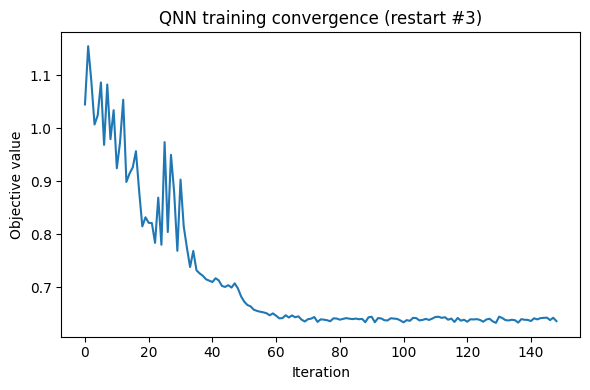

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(training_curves[best_seed])
plt.xlabel("Iteration")
plt.ylabel("Objective value")
plt.title(f"QNN training convergence (restart #{best_seed})")
plt.tight_layout()
plt.show()


## 8. Results Comparison

In [14]:
results_df = pd.DataFrame(results).T
results_df = results_df[["accuracy", "precision", "recall", "f1", "time_sec"]]
results_df.sort_values("accuracy", ascending=False)


,accuracy,precision,recall,f1,time_sec
Logistic Regression (full train set),0.956140,0.958904,0.972222,0.965517,0.006
Classical SVM - RBF (full train set),0.938596,0.957746,0.944444,0.951049,0.008
"Classical SVM - RBF (subsampled, FAIR vs quantum)",0.875000,0.869565,0.909091,0.888889,0.005
QSVM,0.875000,0.840000,0.954545,0.893617,18.630
QNN (best of 5 random restarts),0.750000,0.700000,0.954545,0.807692,69.298


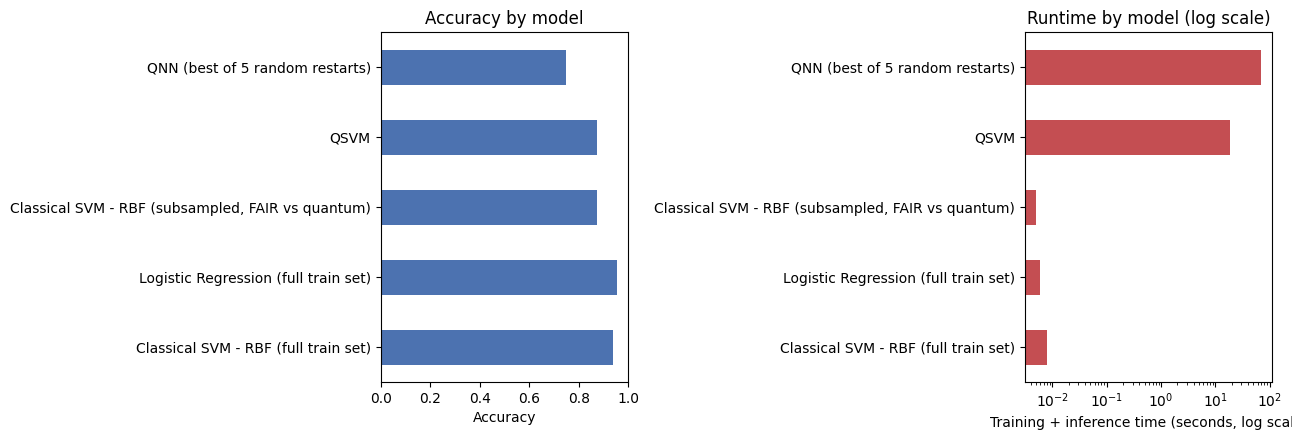

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

results_df["accuracy"].plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_xlabel("Accuracy")
axes[0].set_xlim(0, 1)
axes[0].set_title("Accuracy by model")

results_df["time_sec"].plot(kind="barh", ax=axes[1], color="#C44E52", logx=True)
axes[1].set_xlabel("Training + inference time (seconds, log scale)")
axes[1].set_title("Runtime by model (log scale)")

plt.tight_layout()
plt.show()


**Reading the results:**
- The **QSVM matches the classical SVM trained on the same subsample** — on this reduced-feature, reduced-sample regime, the quantum kernel is competitive with a comparable classical kernel.
- The **QNN underperforms** both classical baselines and the QSVM — consistent with the literature: variational QNN training is harder to converge than either a convex QSVM kernel method or classical gradient-based nets, even with multi-start mitigation.
- **Full-dataset classical models still win outright** on accuracy *and* are 1,000×+ faster — the quantum models were deliberately trained on a small subsample due to simulator cost, which is the central practical limitation of this whole approach today.

## 9. Decision Boundary Visualization (2D)

For a 2D decision-boundary plot we need to be able to plot in the plane, so this section fits fresh 2-feature versions of the classical SVM and QSVM (same pipeline, `N_FEATURES=2`). This is purely for visual intuition — the numeric comparison in Section 8 above uses the real (3-feature) models.

QSVM grid prediction took 27.0s for 400 points


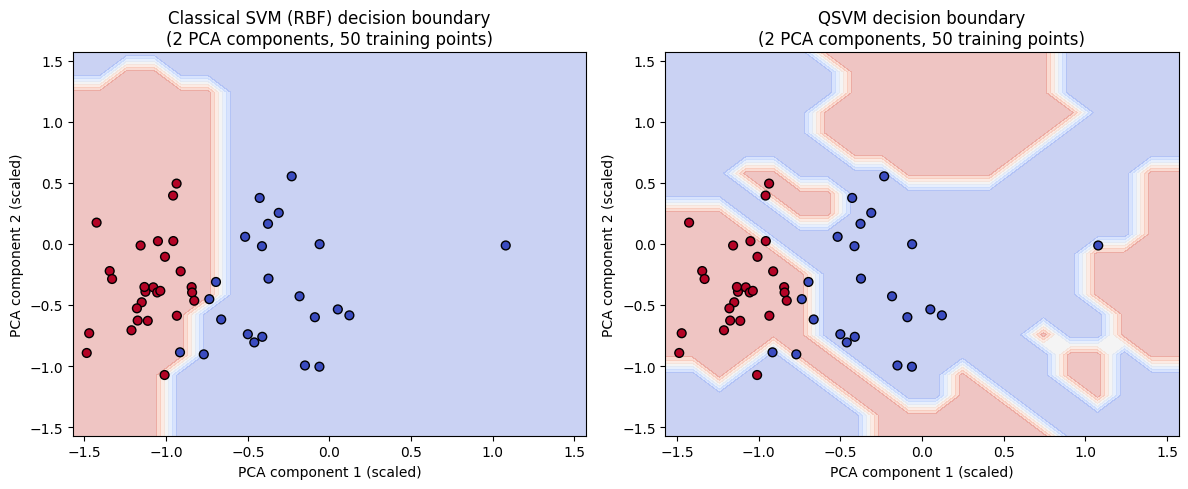

In [16]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_scaled)
mm2 = MinMaxScaler(feature_range=(-np.pi / 2, np.pi / 2))
X_q2 = mm2.fit_transform(X_pca2)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_q2, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
idx2 = np.random.RandomState(RANDOM_STATE).choice(len(X2_train), size=50, replace=False)
X2_train_s, y2_train_s = X2_train[idx2], y2_train[idx2]

fm2 = zz_feature_map(2, reps=1, entanglement="linear")
qsvc2 = QSVC(quantum_kernel=FidelityQuantumKernel(feature_map=fm2))
qsvc2.fit(X2_train_s, y2_train_s)
svm2 = SVC(kernel="rbf", random_state=RANDOM_STATE).fit(X2_train_s, y2_train_s)

# NOTE: the QSVM grid prediction below evaluates a quantum kernel at every grid
# point (~O(grid_size x train_size) circuit executions) - a 20x20 grid takes
# roughly 20-30 seconds on a simulator. This is exactly the runtime cost
# highlighted in Section 8.
xx, yy = np.meshgrid(
    np.linspace(X_q2[:, 0].min(), X_q2[:, 0].max(), 20),
    np.linspace(X_q2[:, 1].min(), X_q2[:, 1].max(), 20),
)
grid = np.c_[xx.ravel(), yy.ravel()]

t0 = time.time()
Z_qsvm = qsvc2.predict(grid).reshape(xx.shape)
print(f"QSVM grid prediction took {time.time()-t0:.1f}s for {grid.shape[0]} points")
Z_svm = svm2.predict(grid).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, Z, title in zip(axes, [Z_svm, Z_qsvm], ["Classical SVM (RBF)", "QSVM"]):
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X2_train_s[:, 0], X2_train_s[:, 1], c=y2_train_s, cmap="coolwarm", edgecolor="k", s=40)
    ax.set_title(f"{title} decision boundary\n(2 PCA components, {len(X2_train_s)} training points)")
    ax.set_xlabel("PCA component 1 (scaled)")
    ax.set_ylabel("PCA component 2 (scaled)")
plt.tight_layout()
plt.show()


## 10. Confusion Matrices

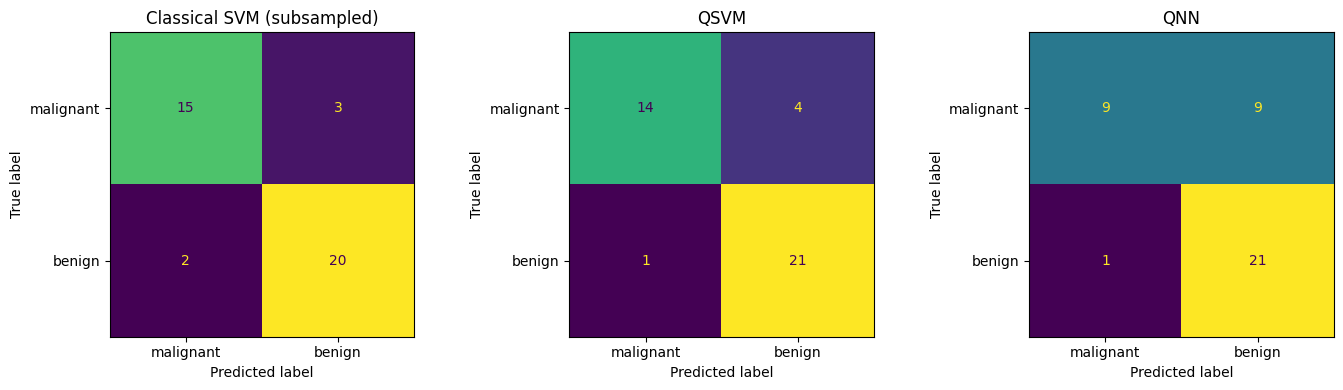

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
model_preds = {
    "Classical SVM (subsampled)": svm_s.predict(X_test_s),
    "QSVM": qsvc.predict(X_test_s),
    "QNN": preds_01,
}
for ax, (name, preds) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_test_s, preds)
    ConfusionMatrixDisplay(cm, display_labels=data.target_names).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


## 11. Limitations & Honest Discussion

**This section is deliberately explicit — a QML project that hides these caveats reads as less credible, not more.**

| Limitation | Detail |
|---|---|
| **No quantum advantage claimed** | On this dataset/regime, classical ML wins on accuracy and is orders of magnitude faster. This is expected and consistent with the current state of NISQ-era QML research. |
| **Small training set for quantum models** | Quantum kernel evaluation is O(n²) circuit executions with no hardware acceleration here; `N_TRAIN=100` was chosen for feasible runtime, not because it's the "right" size. |
| **Simulator only** | No access to real quantum hardware / IBM Quantum backend was used. Real-device results would add sampling noise and hardware error, typically *lowering* accuracy further. |
| **Feature map / scaling sensitivity** | QSVM accuracy was highly sensitive to input scaling range and feature-map depth (see Section 3) — this is a known QML pain point ("barren plateaus" / kernel concentration), not unique to this implementation. |
| **QNN optimization instability** | Even with 5 random restarts, QNN accuracy (70%) trailed the QSVM (87.5%) meaningfully — variational training is genuinely harder to converge reliably than a (nearly) convex kernel method. |
| **Qubit budget** | Limited to 3 qubits (3 PCA components) to keep simulation tractable; this discards a meaningful amount of the original 30-feature signal (~variance explained is reported in Section 3). |

### Next steps (if extending this project)
- Run the QSVM/QNN on real IBM Quantum hardware via `qiskit-ibm-runtime` and compare simulator vs. real-device accuracy/noise.
- Try `PegasosQSVC` (a QSVM variant with faster training) to relax the sample-size constraint.
- Sweep entanglement structure (`linear` vs `circular` vs `full`) and reps systematically, with cross-validation rather than a single train/test split.
- Try an amplitude-encoding feature map instead of angle encoding, to use qubits more efficiently as feature count grows.
